In [98]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import ttest_ind
from matplotlib import cm
from matplotlib import ticker
from scipy.ndimage import gaussian_filter
from experiment_configs import get_experiment_dict
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
import string

In [99]:
class TCCPlotter:
    def __init__(
            self, 
            tci_files_dict, 
            variable,
            windows, 
            landmask_file=None, 
            region=None,  
            compute_ensemble_mean=False
        ):
        self.tci_files = tci_files_dict
        self.variable = variable
        self.windows = list(windows.keys())
        self.projection = ccrs.Robinson()
        self.region = region 
        self.compute_ensemble_mean = compute_ensemble_mean
        
        if landmask_file and os.path.exists(landmask_file):
            ds = xr.open_dataset(landmask_file)
            landmask = ds['landfrac']
            if 'lon' in landmask.coords and landmask.lon.max() > 180:
                landmask['lon'] = ((landmask['lon'] + 180) % 360) - 180
                landmask = landmask.sortby('lon')
            if self.region:
                landmask = landmask.sel(
                    lat=slice(*self.region['lat']), 
                    lon=slice(*self.region['lon'])
                )
            self.landmask = landmask
        else: 
            self.landmask = None 

    def _load_ensemble_data(self, exp, window):
        meta = self.tci_files[exp]
        nens = meta["nens"]
        ftemplate = meta["template"]
        fpath = meta["path"] % {"exp": exp}

        files = []
        for ens in range(1, nens + 1):
            fname = ftemplate % {"exp": exp, "window": window, "ensemble": f"{ens:02d}"}
            full_path = os.path.join(fpath, fname)
            if os.path.exists(full_path):
                files.append(full_path)

        if not files:
            raise FileNotFoundError(f"[ERROR] No {self.variable} files found for {exp} {window}")

        da_list = []
        for k, f in enumerate(files):
            with xr.open_dataset(f) as ds:
                da_list.append(ds[self.variable].expand_dims(ensemble=[k]))

        da = xr.concat(da_list, dim='ensemble')
        if self.region:
            da = da.sel(lat=slice(*self.region['lat']), lon=slice(*self.region['lon']))
        return da

    def _compute_dart_minus_reference_maps(self, dart_exps, reference_exp, percentile,
                                           significance=False, n_boot=1000, alpha=0.05):
        diff_maps = {}
        sig_masks = {}
        global_vmin = np.inf
        global_vmax = -np.inf

        for dart_exp in dart_exps:
            diff_maps[dart_exp] = {}
            sig_masks[dart_exp] = {}
            for window in self.windows:
                try:
                    dart = self._load_ensemble_data(dart_exp, window)
                    ref = self._load_ensemble_data(reference_exp, window)
                except Exception as e:
                    print(f"[ERROR] Failed to load data for {dart_exp} vs {reference_exp} in {window}: {e}")
                    continue

                dim_list = []
                if 'ensemble' in dart.dims:
                    dim_list.append('ensemble')
                if 'time' in dart.dims and dart.sizes.get('time', 1) > 1:
                    dim_list.append('time')

                dart = dart.where(np.isfinite(dart))
                ref = ref.where(np.isfinite(ref))

                dart_p = dart.quantile(percentile, dim=dim_list, skipna=True)
                ref_p = ref.quantile(percentile, dim=dim_list, skipna=True)

                if not dart_p.lat.identical(ref_p.lat) or not dart_p.lon.identical(ref_p.lon):
                    ref_p = ref_p.interp_like(dart_p, method='nearest')

                if self.landmask is not None:
                    landmask_interp = self.landmask.interp_like(dart_p, method='nearest')
                    dart_p = dart_p.where(landmask_interp > 0.5)
                    ref_p = ref_p.where(landmask_interp > 0.5)

                diff = dart_p - ref_p
                diff_maps[dart_exp][window] = diff

                global_vmin = min(global_vmin, float(diff.min()))
                global_vmax = max(global_vmax, float(diff.max()))

                if significance:
                    diffs = dart - ref
                    if self.landmask is not None:
                        diffs = diffs.where(self.landmask > 0.5)

                    if 'time' in diffs.dims and diffs.sizes['time'] > 1:
                        diffs = diffs.mean(dim='time')

                    boot_means = []
                    for _ in range(n_boot):
                        resample = diffs.isel(ensemble=np.random.randint(0, diffs.sizes['ensemble'], diffs.sizes['ensemble']))
                        boot_mean = resample.mean(dim='ensemble', skipna=True)
                        boot_means.append(boot_mean)

                    boot_stack = xr.concat(boot_means, dim='boot')
                    pval = ((boot_stack < 0).sum(dim='boot') / n_boot).where(diff < 0,
                            (boot_stack > 0).sum(dim='boot') / n_boot)
                    sig_mask = pval < alpha
                    if self.landmask is not None:
                        sig_mask = sig_mask.where(self.landmask > 0.5)
                    sig_masks[dart_exp][window] = sig_mask

        return diff_maps, sig_masks, global_vmin, global_vmax

    def _plot_difference_panels(self, diff_maps, sig_masks, dart_exps, reference_exp,
                                cmap, vmin, vmax, significance, levels=None,
                                savepath=None, dpi=150):
        import matplotlib.ticker as mticker
        nrows = len(dart_exps)
        ncols = len(self.windows)
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols,
            figsize=(4 * ncols, 3 * nrows),
            subplot_kw={'projection': self.projection},
            dpi=dpi)

        if nrows == 1:
            axes = [axes]
        if ncols == 1:
            axes = [[ax] for ax in axes]

        bounds = np.linspace(vmin, vmax, 11) if levels is None else levels
        norm = BoundaryNorm(bounds, ncolors=256)
        cmap = cmap or plt.cm.RdBu_r

        row_labels = [f"({letter})" for letter in string.ascii_lowercase[ncols:ncols*2]]
        subplot_labels = row_labels * 2

        for i, dart_exp in enumerate(dart_exps):
            for j, window in enumerate(self.windows):
                ax = axes[i][j]
                idx = i * ncols + j
                diff = diff_maps[dart_exp].get(window)
                if diff is None:
                    ax.set_axis_off()
                    continue

                im = ax.contourf(diff['lon'], diff['lat'], diff.squeeze(),
                                 transform=ccrs.PlateCarree(),
                                 levels=bounds, cmap=cmap, norm=norm, extend='both')

                if significance and window in sig_masks[dart_exp]:
                    sig_mask = sig_masks[dart_exp][window].squeeze()
                    sig_mask_masked = xr.where(sig_mask, np.nan, 1).squeeze()

                    if not np.isnan(sig_mask_masked.values).all():
                        ax.contourf(sig_mask_masked['lon'], sig_mask_masked['lat'], sig_mask_masked,
                                    transform=ccrs.PlateCarree(),
                                    hatches=[".."], colors='none')

                ax.coastlines()
                ax.set_title(f"{subplot_labels[idx]} {dart_exp} - {reference_exp}\n{window}", fontsize=10)

        # Colorbars
        cbar_ax1 = fig.add_axes([0.92, 0.60, 0.01, 0.30])
        sm1 = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm1.set_array([])
        cbar1 = fig.colorbar(sm1, cax=cbar_ax1, ticks=bounds, extend='both')
        cbar1.ax.tick_params(labelsize=10)
        cbar1.ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune='both'))
        cbar1.set_label("ΔTCC", fontsize=10)

        cbar_ax2 = fig.add_axes([0.92, 0.18, 0.01, 0.30])
        sm2 = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm2.set_array([])
        cbar2 = fig.colorbar(sm2, cax=cbar_ax2, ticks=bounds, extend='both')
        cbar2.ax.tick_params(labelsize=10)
        cbar2.ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune='both'))
        cbar2.set_label("ΔTCC", fontsize=10)

        plt.subplots_adjust(left=0.05, right=0.90, bottom=0.08, top=0.94, hspace=0.15, wspace=0.05)

        if savepath:
            plt.savefig(savepath, bbox_inches='tight')
            print(f"[SAVED] {savepath}")
        plt.show()

    def plot_dart_minus_reference_comparison(
            self, reference_exp='CAPTEN10',
            dart_exps=('DARTEN20', 'DARTEN40'),
            percentile=0.95, cmap=None, 
            vmin=None, vmax=None,
            significance=False, n_boot=1000,
            alpha=0.05, levels=None,
            savepath=None, dpi=150):

        cmap = cmap or plt.cm.RdBu_r

        diff_maps, sig_masks, global_vmin, global_vmax = self._compute_dart_minus_reference_maps(
            dart_exps, reference_exp, percentile,
            significance=significance,
            n_boot=n_boot, alpha=alpha)

        vmin = vmin if vmin is not None else global_vmin
        vmax = vmax if vmax is not None else global_vmax

        self._plot_difference_panels(diff_maps, sig_masks, dart_exps, reference_exp,
                                     cmap, vmin, vmax, significance,
                                     levels=levels, savepath=savepath, dpi=dpi)


[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_LHFLX_p90_dart_minus_capten_sig.pdf


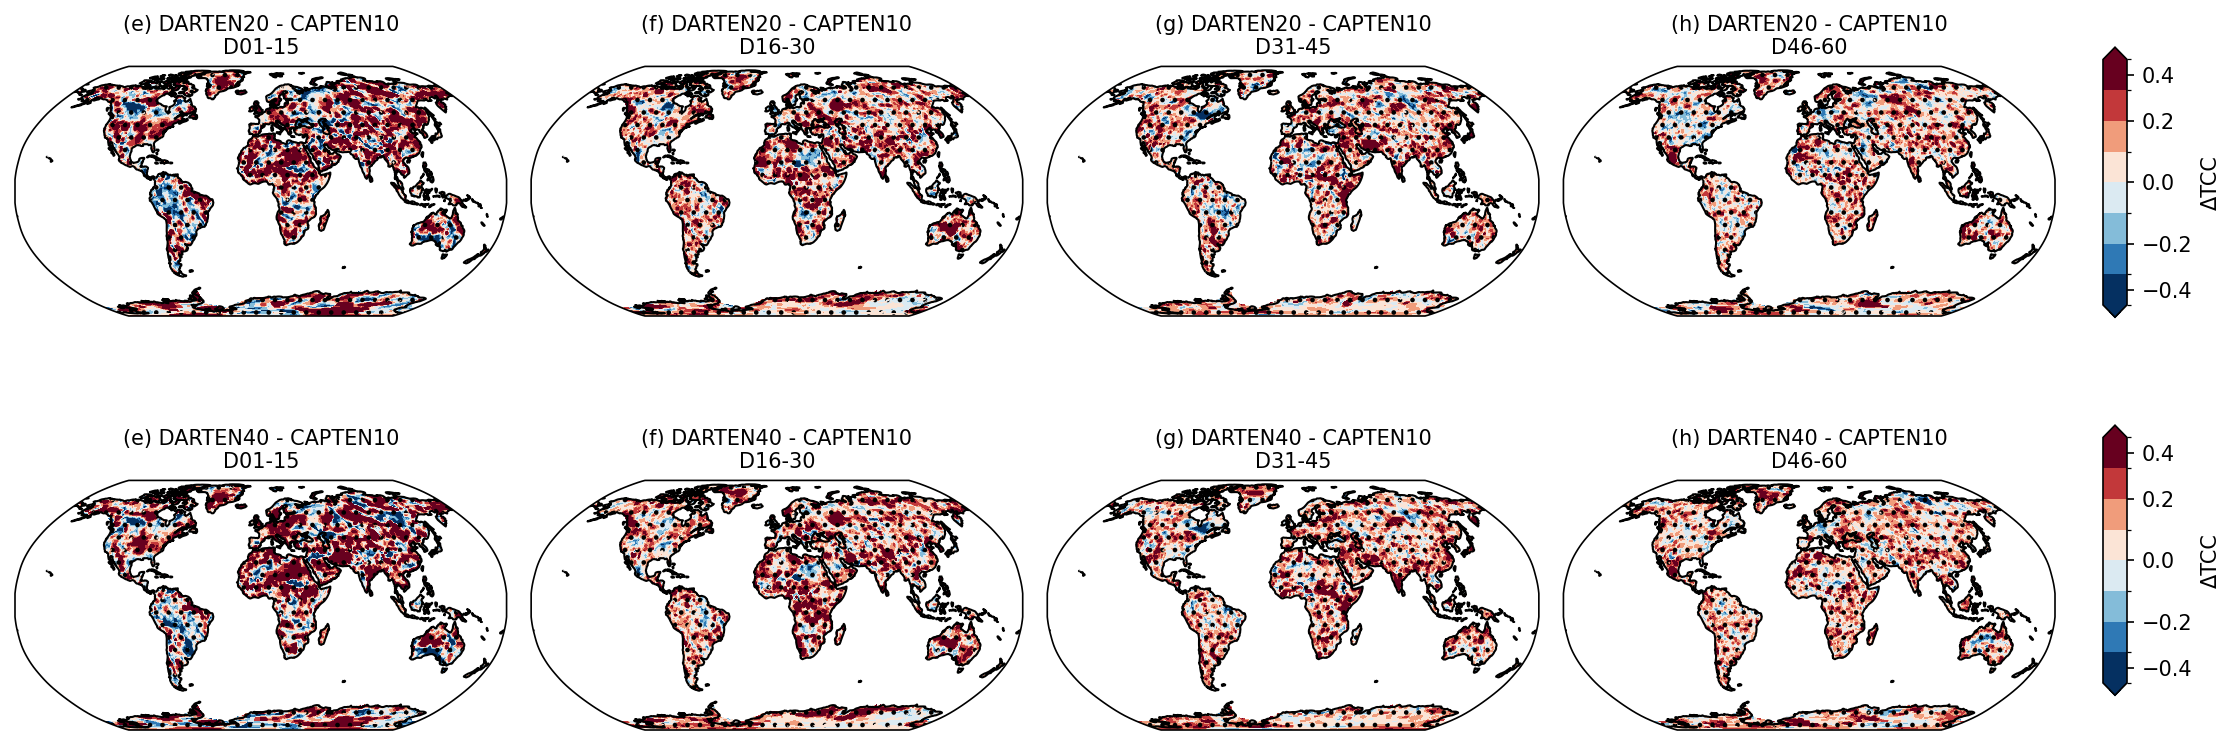

In [100]:
if __name__ == "__main__":
    top_path = "/pscratch/sd/z/zhan391/e3sm_dart"
    out_path = os.path.join(top_path, "diag_dart")
    landmask_file = os.path.join(out_path, "landmask_1x1.nc")
    fig_path = "/global/homes/z/zhan391/analysis/diagnostic/figures"
    os.makedirs(fig_path, exist_ok=True)

    # Define region before using it in the plotter
    region = {'lat': (-90, 90), 'lon': (-180, 180)}

    # Define the windows
    windows = {
        "D01-15": "D01-15",
        "D16-30": "D16-30",
        "D31-45": "D31-45",
        "D46-60": "D46-60",
    }

    # Variable and key setup
    variable = "TCC"
    key = "LHFLX"  # or "SOILWATER_10CM_LHFLX"
    
    # Define the TCI file dictionary
    tci_files_dict = {
        'CTRLEN10': {
            "path": f'{out_path}/%(exp)s',
            "nens": 10,
            "template": f'fcst_tcc_rmse_%(exp)s_EN%(ensemble)s_{key}_%(window)s.nc'
        },
        'CAPTEN10': {
            "path": f'{out_path}/%(exp)s',
            "nens": 10,
            "template": f'fcst_tcc_rmse_%(exp)s_EN%(ensemble)s_{key}_%(window)s.nc'
        },
        'DARTEN20': {
            "path": f'{out_path}/%(exp)s',
            "nens": 20,
            "template": f'fcst_tcc_rmse_%(exp)s_EN%(ensemble)s_{key}_%(window)s.nc'
        },
        'DARTEN40': {
            "path": f'{out_path}/%(exp)s',
            "nens": 40,
            "template": f'fcst_tcc_rmse_%(exp)s_EN%(ensemble)s_{key}_%(window)s.nc'
        }
    }

    # Initialize TCCPlotter after defining region
    plotter = TCCPlotter(
        tci_files_dict=tci_files_dict,
        variable=variable,
        windows=windows,
        region=region,
        landmask_file=landmask_file,
        compute_ensemble_mean=True
    )

    # Define color scale for plotting
    levels = [-0.5, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.5]
    vmin = np.min(levels)
    vmax = np.max(levels)
    
    # --- Main: Plot DART - CAPTEN comparison with significance hatching over land ---
    savefile = os.path.join(fig_path, f"TCC_{key}_p90_dart_minus_capten_sig.pdf")
    plotter.plot_dart_minus_reference_comparison(
        reference_exp='CAPTEN10',
        dart_exps=('DARTEN20', 'DARTEN40'),
        percentile=0.9,
        levels=levels,  
        vmin=vmin,
        vmax=vmax,
        significance=True,
        n_boot=1000,
        alpha=0.05,
        savepath=savefile
    )